# 03 — Statistical analysis

This notebook examines distribution shape, robust summaries, outliers, and monotonic relationships before interpreting the opportunity score.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
ANALYSIS = ROOT / "data" / "processed" / "analysis"
data = pd.read_csv(ANALYSIS / "district_opportunities.csv")
columns = [
    "transaction_count",
    "transaction_amount",
    "registered_users",
    "registered_merchants",
    "transaction_yoy",
    "merchants_per_100k_users",
    "users_per_merchant",
    "transactions_per_merchant",
]
stats = data[columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
stats["skewness"] = data[columns].skew()
stats["iqr"] = stats["75%"] - stats["25%"]
display(stats.round(3))

,count,mean,std,min,10%,25%,50%,75%,90%,max,skewness,iqr
transaction_count,680.0,5.672571e+07,1.175779e+08,1.132307e+06,6.509869e+06,1.341040e+07,3.027936e+07,6.337847e+07,1.049682e+08,2.113433e+09,10.549,4.996807e+07
transaction_amount,680.0,6.674380e+10,1.263090e+11,1.671649e+09,7.485972e+09,1.570600e+10,3.657015e+10,7.577681e+10,1.389459e+11,2.237235e+12,9.877,6.007082e+10
registered_users,680.0,1.041589e+06,1.392570e+06,1.007420e+05,2.292631e+05,4.043760e+05,7.047250e+05,1.212390e+06,1.997998e+06,2.054306e+07,6.876,8.080142e+05
registered_merchants,680.0,7.442741e+04,1.132358e+05,1.244000e+03,1.085600e+04,2.207900e+04,4.611000e+04,8.609775e+04,1.479586e+05,1.517644e+06,6.522,6.401875e+04
transaction_yoy,680.0,2.510000e-01,6.400000e-02,-2.600000e-02,1.760000e-01,2.080000e-01,2.510000e-01,2.930000e-01,3.270000e-01,5.240000e-01,0.095,8.500000e-02
merchants_per_100k_users,680.0,6.516358e+03,1.947399e+03,9.154310e+02,4.079322e+03,5.278219e+03,6.441486e+03,7.751068e+03,8.995613e+03,1.447934e+04,0.220,2.472849e+03
users_per_merchant,680.0,1.721300e+01,7.711000e+00,6.906000e+00,1.111700e+01,1.290100e+01,1.552400e+01,1.894600e+01,2.451400e+01,1.092380e+02,4.548,6.044000e+00
transactions_per_merchant,680.0,7.831000e+02,4.564440e+02,1.230470e+02,3.138920e+02,4.646620e+02,6.756770e+02,9.986240e+02,1.394571e+03,4.159401e+03,1.838,5.339620e+02


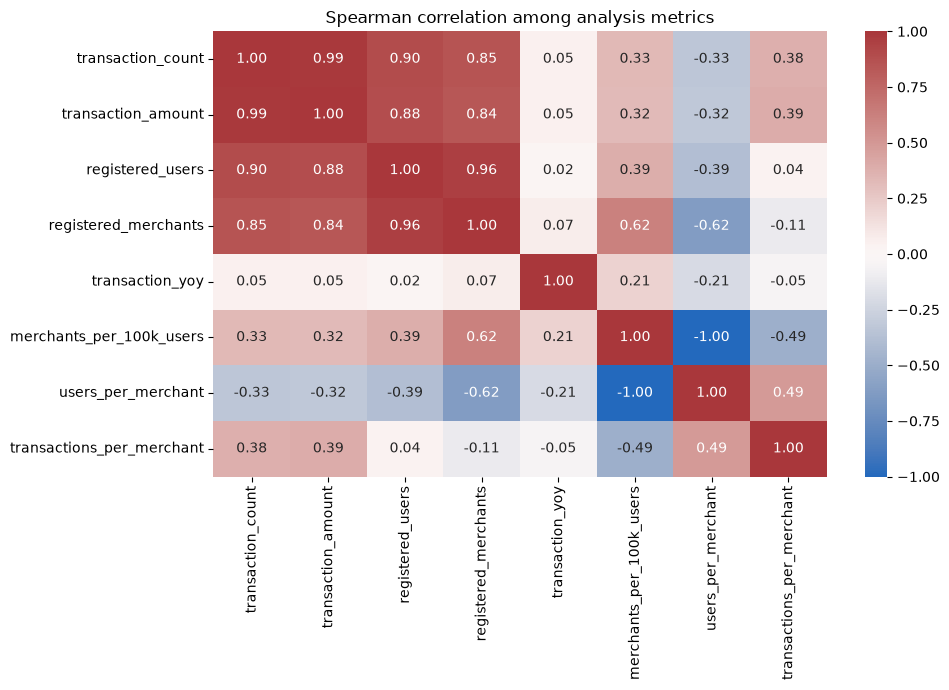

In [2]:
corr = data[columns].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Spearman correlation among analysis metrics")
plt.tight_layout()
plt.show()

Spearman correlation is used because the metrics are skewed, contain outliers, and are more plausibly monotonic than linear. Correlation does not establish causation. Ratios that share the merchant denominator can also correlate mechanically, so transaction intensity is tested in a sensitivity scenario rather than treated as unquestioned evidence.